# Segmentación de Clientes - Análisis Refinado

En este notebook trabajaremos con una base de datos de facturación (invoice data) que contiene información sobre ventas, clientes y transacciones. Nuestro objetivo es realizar una segmentación de clientes basada en sus características, pero con un enfoque depurado para evitar que las categorías queden demasiado amontonadas.

### Columnas principales:
- **invoice_no:** Número de factura
- **customer_id:** Identificador del cliente
- **gender:** Género
- **age:** Edad del cliente
- **category:** Categoría del producto (Clothing, Shoes, Books, etc.)
- **quantity:** Cantidad comprada
- **price:** Precio unitario
- **payment_method:** Método de pago (Credit Card, Debit Card, Cash, etc.)
- **invoice_date:** Fecha de la factura
- **shopping_mall:** Centro comercial donde se realizó la compra

### Objetivos del Taller:

1. Explorar, limpiar y entender la base de datos.
2. Crear variables derivadas (por ejemplo, el valor total de la compra).
3. Reducir la cantidad de categorías (por ejemplo, agrupar aquellas con muy pocos registros) para lograr un análisis más claro.
4. Definir criterios de segmentación demográfica y comportamental.
5. Visualizar los segmentos usando la paleta corporativa.
6. Formular preguntas específicas para discutir implicaciones de marketing.

### Paleta Corporativa a Utilizar:
- Azul: `#0033A0`
- Naranja: `#FF6600`
- Blanco: `#FFFFFF`

¡Sigan cada paso y al final discutan qué implicaciones de marketing se derivan de cada segmento!

In [ ]:
!wget https://github.com/javierherrera1996/IntroMarketingAnalytics/raw/refs/heads/main/SegundoCorte/customer_shopping_data.csv.zip

--2025-10-20 23:23:30--  https://github.com/javierherrera1996/IntroMarketingAnalytics/raw/refs/heads/main/SegundoCorte/customer_shopping_data.csv.zip
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/javierherrera1996/IntroMarketingAnalytics/refs/heads/main/SegundoCorte/customer_shopping_data.csv.zip [following]
--2025-10-20 23:23:30--  https://raw.githubusercontent.com/javierherrera1996/IntroMarketingAnalytics/refs/heads/main/SegundoCorte/customer_shopping_data.csv.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1712272 (1.6M) [application/zip]
Saving to: ‘customer_shopping_data.csv.zip’

cus

In [ ]:
!unzip customer_shopping_data.csv.zip

Archive:  customer_shopping_data.csv.zip
  inflating: customer_shopping_data.csv  


In [ ]:
# =============================================================================
# IMPORTS Y CONFIGURACIONES INICIALES
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Paleta corporativa
corporate_colors = ['#0033A0', '#FF6600', '#FFFFFF']

# Ajuste de estética con Seaborn
sns.set(style="whitegrid")
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=corporate_colors)

print("Configuración inicial completa. Recuerden usar la paleta corporativa en sus gráficos.")

Configuración inicial completa. Recuerden usar la paleta corporativa en sus gráficos.


## 1. Carga y Vista Rápida del Dataset

Carguen la base de datos denominada `customer_shopping_data.csv`. Observen las dimensiones y las primeras filas para familiarizarse con la estructura de los datos.

In [ ]:
# =============================================================================
# 1. CARGA Y VISTA RÁPIDA DEL DATASET
# =============================================================================

df = pd.read_csv('customer_shopping_data.csv')

print("Dimensiones del DataFrame:")
print(df.shape)

print("\nVista rápida de los primeros registros:")
df.head()

Dimensiones del DataFrame:
(99457, 10)

Vista rápida de los primeros registros:


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


## 2. Análisis Exploratorio Inicial

Revisen la estructura, los tipos de datos y las estadísticas descriptivas del dataset.

**Pregunta para los estudiantes:** ¿Qué columnas consideran críticas para segmentar a los clientes y por qué?

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000


Las columnas que yo considero que se deben evalar son: edad. categoria y precio

## 3. Limpieza de Datos

Identifiquen y gestionen valores nulos y duplicados. Es esencial dejar la base limpia para un análisis confiable.

**Pregunta:** ¿Qué variables presentan problemas de calidad de datos y cómo los resolverían?

In [ ]:
print("Cantidad de valores nulos por columna:")
print(df.isnull().sum())

Cantidad de valores nulos por columna:
invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64


No hay variables nulas

## 4. Creación de Variables Derivadas

Generen nuevas variables que puedan aportar a la segmentación. Por ejemplo, calculen el **valor total** de la factura (multiplicar `quantity` por `price`).

**Pregunta:** ¿Qué otras variables derivadas podrían ser útiles para analizar el comportamiento de compra?

In [ ]:
TotalPrice=df['quantity']*df['price']
df['total_value']=TotalPrice
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,total_value
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon,7502.00
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul,5401.53
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity,300.08
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM,15004.25
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon,242.40


Otras variales importantes a tener en cuenta son: edad y tipo de producto (category), edad y precio, edad y genero.

## 5. Visualización de Distribuciones

Visualicen la distribución de variables clave, como `age` y `total_value`, usando histogramas y boxplots. Usen la paleta corporativa en los gráficos.

**Pregunta:** ¿Detectan patrones o valores atípicos que requieran atención?

In [ ]:
import matplotlib.pyplot as plt

paleta = ["#0033A0", "#FF6600", "#FFFFFF"]

Text(0.5, 1.0, 'Valor Total')

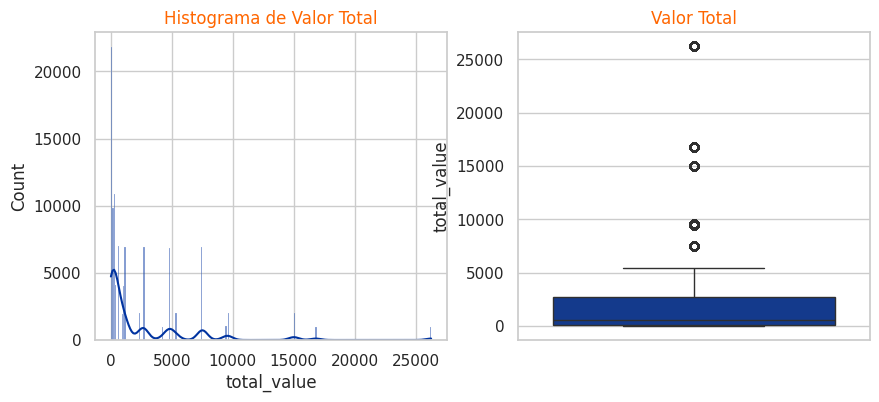

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['total_value'], kde=True)
plt.title(f'Histograma de Valor Total', color=paleta[1])

plt.subplot(1,2,2)
sns.boxplot(y=df['total_value'])
plt.title('Valor Total', color=paleta[1])

Text(0.5, 1.0, 'Valor Edad')

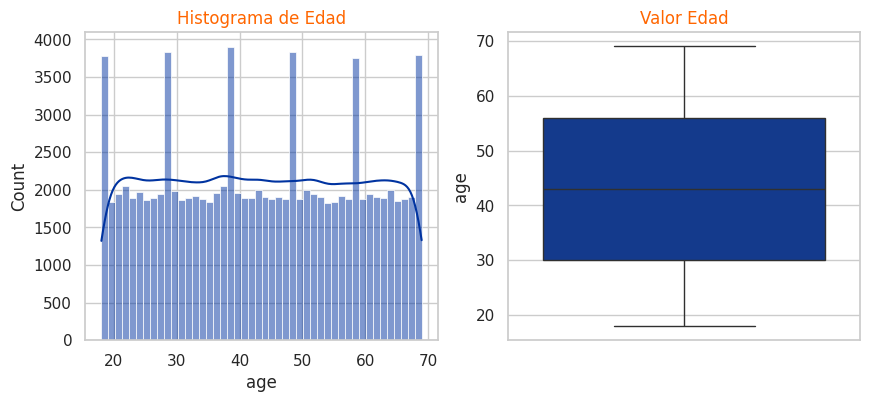

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['age'], kde=True)
plt.title(f'Histograma de Edad', color=paleta[1])

plt.subplot(1,2,2)
sns.boxplot(y=df['age'])
plt.title('Valor Edad', color=paleta[1])

Las gráficas correspondientes a valor total muestran que las personas en a mayoria de casos compran por un bajo monto y en casos putuales hay compras con valores altos. Por otro lado, las gráficas de edad muestran la mediana correponde a las personas con rangos de edad entre 40 y 45 años, también muestra que los datos están repartidos de manera similar en casi todos los rangos de edad

## 6. Definición de Criterios de Segmentación Demográfica

Segmenten a los clientes en función de variables demográficas, por ejemplo, agrupando la edad en categorías (Jóvenes, Adultos, Mayores) y analizando el género.

**Pregunta:** ¿Cómo segmentarían a los clientes en función de la edad y el género para dirigir campañas específicas?

In [ ]:
bins_edad = [0, 30, 50, 100]
labels_edad = ['Joven', 'Adulto', 'Mayor']
df['Segmento_Edad'] = pd.cut(df['age'], bins=bins_edad, labels=labels_edad, right=False)
df["Segmento_Edad"].value_counts()

,count
Segmento_Edad,
Adulto,38440
Mayor,37974
Joven,23043


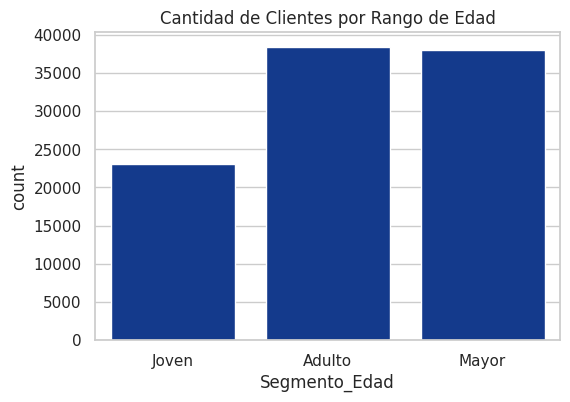

In [ ]:
df["Segmento_Edad"].value_counts()
plt.figure(figsize=(6,4))
sns.countplot(x='Segmento_Edad', data=df)
plt.title('Cantidad de Clientes por Rango de Edad')
plt.show()

In [ ]:
def asignar_segmento(row):
    return f"{row['Segmento_Edad']}_{row['gender']}"

df['Segmento_Edad'] = df.apply(asignar_segmento, axis=1)
seg_counts = df['Segmento_Edad'].value_counts().reset_index()
seg_counts.columns = ['Segmento_Edad', 'gender']
seg_counts

,Segmento_Edad,gender
0,Adulto_Female,23040
1,Mayor_Female,22715
2,Adulto_Male,15400
3,Mayor_Male,15259
4,Joven_Female,13727
5,Joven_Male,9316


## 7. Definición de Criterios de Segmentación Comportamental

Segmenten a los clientes según su comportamiento de compra. Revisen variables como `category`, `payment_method` y `shopping_mall`.

**Pregunta:** ¿Qué comportamiento de compra (categoría, método de pago, centro comercial) consideran de mayor impacto para la estrategia de marketing? ¿Por qué?

In [ ]:
df.info()
df[['category', 'payment_method', 'shopping_mall']].head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
 10  total_value     99457 non-null  float64
 11  Segmento_Edad   99457 non-null  object 
dtypes: float64(2), int64(2), object(8)
memory usage: 9.1+ MB


,category,payment_method,shopping_mall
0,Clothing,Credit Card,Kanyon
1,Shoes,Debit Card,Forum Istanbul
2,Clothing,Cash,Metrocity
3,Shoes,Credit Card,Metropol AVM
4,Books,Cash,Kanyon


In [ ]:
df['TotalPrice'] = df['quantity'] * df['price']
gasto_cliente = df.groupby('customer_id')['TotalPrice'].sum().reset_index()
gasto_cliente.head()
gasto_cliente['Segmento_Gasto'] = pd.cut(
    gasto_cliente['TotalPrice'],
    bins=[-1, 200, 500, 2000, 50000],
    labels=['Gasto_Bajo', 'Gasto_Medio', 'Gasto_Alto', 'Cliente_Premium']
)
gasto_cliente.head()

,customer_id,TotalPrice,Segmento_Gasto
0,C100004,7502.00,Cliente_Premium
1,C100005,2400.68,Cliente_Premium
2,C100006,322.56,Gasto_Medio
3,C100012,130.75,Gasto_Bajo
4,C100019,35.84,Gasto_Bajo


In [ ]:
df_segmentado = pd.merge(df, gasto_cliente, on='customer_id')
df_segmentado.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,total_value,Segmento_Edad,TotalPrice_x,TotalPrice_y,Segmento_Gasto
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon,7502.00,Joven_Female,7502.00,7502.00,Cliente_Premium
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul,5401.53,Joven_Male,5401.53,5401.53,Cliente_Premium
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity,300.08,Joven_Male,300.08,300.08,Gasto_Medio
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM,15004.25,Mayor_Female,15004.25,15004.25,Cliente_Premium
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon,242.40,Mayor_Female,242.40,242.40,Gasto_Medio


In [ ]:
df_segmentado.groupby('category')['Segmento_Gasto'].value_counts(normalize=True)

category         Segmento_Gasto 
Books            Gasto_Bajo         0.600883
                 Gasto_Medio        0.399117
                 Gasto_Alto         0.000000
                 Cliente_Premium    0.000000
Clothing         Cliente_Premium    0.600110
                 Gasto_Alto         0.201525
                 Gasto_Medio        0.198365
                 Gasto_Bajo         0.000000
Cosmetics        Gasto_Alto         0.401735
                 Gasto_Bajo         0.394780
                 Gasto_Medio        0.203484
                 Cliente_Premium    0.000000
Food & Beverage  Gasto_Bajo         1.000000
                 Gasto_Medio        0.000000
                 Gasto_Alto         0.000000
                 Cliente_Premium    0.000000
Shoes            Cliente_Premium    0.806259
                 Gasto_Alto         0.193741
                 Gasto_Bajo         0.000000
                 Gasto_Medio        0.000000
Souvenir         Gasto_Bajo         0.801560
                 Gasto_Medio        0.198440
                 Gasto_Alto         0.000000
                 Cliente_Premium    0.000000
Technology       Cliente_Premium    0.802842
                 Gasto_Alto         0.197158
                 Gasto_Bajo         0.000000
                 Gasto_Medio        0.000000
Toys             Gasto_Alto         0.401209
                 Gasto_Bajo         0.392386
                 Gasto_Medio        0.206404
                 Cliente_Premium    0.000000
Name: proportion, dtype: float64

In [ ]:
df_segmentado.groupby('payment_method')['Segmento_Gasto'].value_counts(normalize=True)

payment_method  Segmento_Gasto 
Cash            Cliente_Premium    0.330528
                Gasto_Bajo         0.319212
                Gasto_Alto         0.201453
                Gasto_Medio        0.148806
Credit Card     Cliente_Premium    0.328705
                Gasto_Bajo         0.318084
                Gasto_Alto         0.201054
                Gasto_Medio        0.152157
Debit Card      Cliente_Premium    0.329897
                Gasto_Bajo         0.318492
                Gasto_Alto         0.199910
                Gasto_Medio        0.151701
Name: proportion, dtype: float64

In [ ]:
df_segmentado.groupby('shopping_mall')['Segmento_Gasto'].value_counts(normalize=True)

shopping_mall      Segmento_Gasto 
Cevahir AVM        Cliente_Premium    0.325386
                   Gasto_Bajo         0.321779
                   Gasto_Alto         0.194951
                   Gasto_Medio        0.157884
Emaar Square Mall  Cliente_Premium    0.340678
                   Gasto_Bajo         0.314903
                   Gasto_Alto         0.197672
                   Gasto_Medio        0.146747
Forum Istanbul     Cliente_Premium    0.330301
                   Gasto_Bajo         0.327269
                   Gasto_Alto         0.199111
                   Gasto_Medio        0.143319
Istinye Park       Cliente_Premium    0.330028
                   Gasto_Bajo         0.321337
                   Gasto_Alto         0.200593
                   Gasto_Medio        0.148042
Kanyon             Cliente_Premium    0.328961
                   Gasto_Bajo         0.319982
                   Gasto_Alto         0.199617
                   Gasto_Medio        0.151440
Mall of Istanbul   Cliente_Premium    0.330241
                   Gasto_Bajo         0.314697
                   Gasto_Alto         0.202176
                   Gasto_Medio        0.152886
Metrocity          Cliente_Premium    0.326561
                   Gasto_Bajo         0.319033
                   Gasto_Alto         0.204250
                   Gasto_Medio        0.150157
Metropol AVM       Cliente_Premium    0.330184
                   Gasto_Bajo         0.319555
                   Gasto_Alto         0.200472
                   Gasto_Medio        0.149788
Viaport Outlet     Cliente_Premium    0.331298
                   Gasto_Bajo         0.314815
                   Gasto_Alto         0.203297
                   Gasto_Medio        0.150590
Zorlu Center       Cliente_Premium    0.331034
                   Gasto_Bajo         0.317044
                   Gasto_Alto         0.202759
                   Gasto_Medio        0.149163
Name: proportion, dtype: float64

La variable de mayor importancia para la estratégia de marketing sería la "categoria", debido a que esta nos ayudaría a segmentar con mayor precisión al público de acuerdo a su gasto en cada producto. Por ejemplo, conocer que tipo de productos le interesan más a los clientes premium.

## 8. Visualizaciones Comparativas de Segmentos

Crucen variables demográficas y comportamentales para identificar relaciones relevantes. Por ejemplo, comparen el grupo de edad con la categoría de producto.

**Pregunta:** ¿Qué relaciones entre estas variables podrían definir segmentos de alto valor?

In [69]:
df_segmentado.groupby(['Segmento_Edad'])['category'].value_counts(normalize=True)

Segmento_Edad  category       
Adulto_Female  Clothing           0.348394
               Cosmetics          0.151649
               Food & Beverage    0.148958
               Toys               0.100868
               Shoes              0.099826
               Technology         0.051215
               Souvenir           0.050391
               Books              0.048698
Adulto_Male    Clothing           0.343052
               Cosmetics          0.153312
               Food & Beverage    0.150909
               Shoes              0.100260
               Toys               0.099481
               Technology         0.053247
               Souvenir           0.050519
               Books              0.049221
Joven_Female   Clothing           0.350113
               Cosmetics          0.151016
               Food & Beverage    0.145115
               Toys               0.104903
               Shoes              0.100459
               Souvenir           0.050339
               Technology         0.049610
               Books              0.048445
Joven_Male     Clothing           0.347467
               Food & Beverage    0.150923
               Cosmetics          0.143839
               Toys               0.103800
               Shoes              0.103371
               Books              0.053349
               Souvenir           0.049270
               Technology         0.047982
Mayor_Female   Clothing           0.344222
               Cosmetics          0.154215
               Food & Beverage    0.148800
               Toys               0.102179
               Shoes              0.100726
               Souvenir           0.051288
               Technology         0.049307
               Books              0.049263
Mayor_Male     Clothing           0.348319
               Cosmetics          0.152435
               Food & Beverage    0.146930
               Shoes              0.102235
               Toys               0.098499
               Books              0.053739
               Technology         0.049020
               Souvenir           0.048824
Name: proportion, dtype: float64

Tabla cruzada (Edad vs Categoria):
category       Books  Clothing  Cosmetics  Food & Beverage  Shoes  Souvenir  \
Segmento_Edad                                                                 
Adulto_Female   1122      8027       3494             3432   2300      1161   
Adulto_Male      758      5283       2361             2324   1544       778   
Joven_Female     665      4806       2073             1992   1379       691   
Joven_Male       497      3237       1340             1406    963       459   
Mayor_Female    1119      7819       3503             3380   2288      1165   
Mayor_Male       820      5315       2326             2242   1560       745   

category       Technology  Toys  
Segmento_Edad                    
Adulto_Female        1180  2324  
Adulto_Male           820  1532  
Joven_Female          681  1440  
Joven_Male            447   967  
Mayor_Female         1120  2321  
Mayor_Male            748  1503  


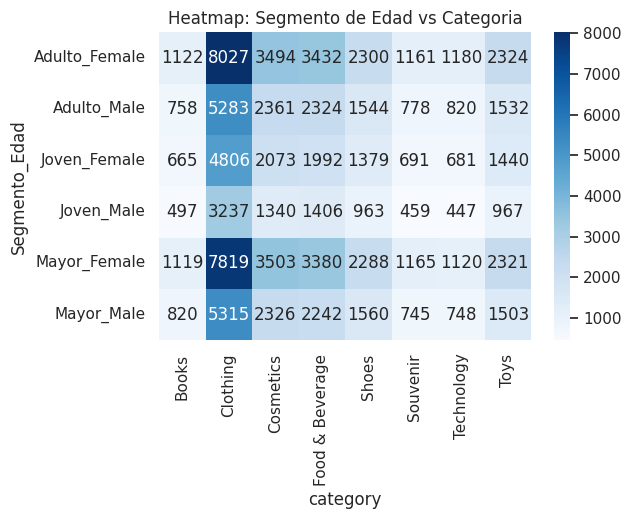

In [66]:
tabla_segmentos = pd.crosstab(df['Segmento_Edad'], df['category'])
print("Tabla cruzada (Edad vs Categoria):")
print(tabla_segmentos)

plt.figure(figsize=(6,4))
sns.heatmap(tabla_segmentos, annot=True, cmap='Blues', fmt='d')
plt.title('Heatmap: Segmento de Edad vs Categoria')
plt.show()

La mayoria de clientes compran ropa y en su mayoria son mujeres, especialmente adultas y mayores. Y lo que menos compran son productos de tecnológia. Las mujeres mayores y adultas son quienes más compran a modo general. Las categorías secundarias serían cosmeticos y comida.



## 9. Reducción y Agrupación de Categorías

Si encuentran que hay demasiadas categorías o que algunas tienen muy pocos registros, agrupen aquellas que sean similares o con bajo volumen para evitar análisis amontonados.

**Ejemplo:** Si hay muchas categorías de tecnología o juguetes con pocos registros, podrían agruparlas en "Otros" o "Tecnología/Entretenimiento".

**Pregunta:** ¿Qué categorías agruparían y por qué?

In [96]:
mapping = {
    'Technology': 'Entretenimiento',
    'Toys': 'Entretenimiento',
    'Books': 'Entretenimiento',
}
df['category_mapped'] = df['category'].replace(mapping)

vc2 = df['category_mapped'].value_counts()
rare_after_map = vc2[vc2 / len(df) < 0.01].index.tolist()
df['category_final'] = df['category_mapped'].where(~df['category_mapped'].isin(rare_after_map), other='Other')

display(df['category'].value_counts().head(30))
display(df['category_final'].value_counts().head(30))

,count
category,
Clothing,34487
Cosmetics,15097
Food & Beverage,14776
Toys,10087
Shoes,10034
Souvenir,4999
Technology,4996
Books,4981


,count
category_final,
Clothing,34487
Entretenimiento,20064
Cosmetics,15097
Food & Beverage,14776
Shoes,10034
Souvenir,4999


Agrupe tecnología, juguetes y libros en entretenimiento ya que cuentan con pocos registros y el tipo de producto tiene correlación.

## 10. Creación de Segmentación Manual Combinada

Combinen criterios demográficos (por ejemplo, grupo de edad) y comportamentales (por ejemplo, categoría reducida y shopping mall) para formar un único segmento combinado.

**Pregunta:** ¿Qué combinación de variables creen que ofrece el perfil más completo para orientar estrategias de marketing?

In [102]:
def asignar_segmento(row):
    return f"{row['Segmento_Edad']}_{row['category_final']}"

df['Segmento_Comb'] = df.apply(asignar_segmento, axis=1)
seg_counts = df['Segmento_Comb'].value_counts().reset_index()
seg_counts.columns = ['Segmento_Comb', 'Cantidad']
seg_counts

,Segmento_Comb,Cantidad
0,Adulto_Female_Clothing,8027
1,Mayor_Female_Clothing,7819
2,Mayor_Male_Clothing,5315
3,Adulto_Male_Clothing,5283
4,Joven_Female_Clothing,4806
5,Adulto_Female_Entretenimiento,4626
6,Mayor_Female_Entretenimiento,4560
7,Mayor_Female_Cosmetics,3503
8,Adulto_Female_Cosmetics,3494
9,Adulto_Female_Food & Beverage,3432


In [101]:
def asignar_segmento(row):
    return f"{row['Segmento_Edad']}_{row['shopping_mall']}"

df['Segmento_Comb'] = df.apply(asignar_segmento, axis=1)
seg_counts = df['Segmento_Comb'].value_counts().reset_index()
seg_counts.columns = ['Segmento_Comb', 'Cantidad']
seg_counts

,Segmento_Comb,Cantidad
0,Adulto_Female_Kanyon,4637
1,Mayor_Female_Mall of Istanbul,4592
2,Adulto_Female_Mall of Istanbul,4560
3,Mayor_Female_Kanyon,4544
4,Mayor_Female_Metrocity,3431
5,Adulto_Female_Metrocity,3430
6,Adulto_Male_Mall of Istanbul,3109
7,Adulto_Male_Kanyon,3083
8,Mayor_Male_Mall of Istanbul,3035
9,Mayor_Male_Kanyon,3025


In [105]:
def asignar_segmento(row):
    return f"{row['category_final']}_{row['shopping_mall']}"

df['Segmento_Comb'] = df.apply(asignar_segmento, axis=1)
seg_counts = df['Segmento_Comb'].value_counts().reset_index()
seg_counts.columns = ['Segmento_Comb', 'Cantidad']
seg_counts

,Segmento_Comb,Cantidad
0,Clothing_Mall of Istanbul,6923
1,Clothing_Kanyon,6840
2,Clothing_Metrocity,5268
3,Entretenimiento_Mall of Istanbul,4042
4,Entretenimiento_Kanyon,3997
5,Clothing_Metropol AVM,3525
6,Clothing_Istinye Park,3353
7,Cosmetics_Mall of Istanbul,3050
8,Entretenimiento_Metrocity,3039
9,Cosmetics_Kanyon,3023


Edad+genero + categoria / categoria + centro comercial

## 11. Análisis Final de los Grupos Resultantes

Analicen cómo se comportan los segmentos combinados en relación al **valor total de compra**. Identifiquen cuáles tienen un alto valor promedio y discutan sus implicaciones para la estrategia de marketing.

**Pregunta:** ¿Qué segmento destaca por tener un alto valor total y qué estrategias sugerirían para potenciarlo?

El segmento Cliente Premium es el que más destaca por valor total de compra. En la muestra de facturas, este segmento concentra el mayor ingreso por factura y un alto valor promedio por compra, lo que lo convierte en prioritario para acciones de retención y expansión. Ya que los clientes premium son mayoritarios en nuestro negocio, se debería implementar un programa VIP con beneficios exclusivos (envío gratuito, accesos anticipados y atención prioritaria), junto con recomendaciones personalizadas basadas en historial de compra y malls preferidos. Con esto se busca aumentar frecuencia y fidelizar a nuestros clientes, manteniendo márgenes, y deben monitorearse con KPIs como ingresos por segmento, AOV, tasa de repetición y retención días. Por otro lado, se debe buscar la migración de clientes medios y altos a clientes premium.



## 12. Recomendaciones de Marketing

Con base en el análisis de los segmentos, respondan las siguientes preguntas:

- ¿Qué segmentos tienen mayor potencial en términos de valor y frecuencia de compra?
- ¿Qué estrategias de marketing implementarían para segmentos con bajo valor promedio?
- ¿Cómo influye la categoría de producto (tras la reducción) y el centro comercial en el comportamiento de compra?

Escriban sus respuestas en una celda Markdown o en un documento complementario, justificando cada estrategia.

Los segmentos con mayor potencial son: gasto alto y cliente premium, con una preferencia por los productos de vestir: ropa y calzado, con mayor frecuencia de compra. Adicionalmente, los clientes prefieren comprar en estos centros comerciales: Metropol, Kanyon y Forum.
Teniendo en cuenta los datos, estos clientes son bastante representativos y muestran comportamientos de lealtad. Por esto, es importante centrarnos en ellos y migrar a los clientes medios y altos para que se coviertan en clientes premium: para esto sería bueno realizar una campaña de fidelización.
Para los clientes premium, se debería implementar un prgrama/membresia VIP que le den acceso a descuentos, prioridades en eventos (comerciales y de experiencia de usuario), personalización en sugerencias 1:1 por canales de comunicación directos (de acuerdo a su comportamiento de compra), atención personalizada y programa de referidos.
Para los clientes de gasto bajo (incluso para todos los clientes) se podría incluir gamificación en el proceso de compra, activación en cc que frecuentan las personas de gasto bajo, por medio de recompensas y CTA con los beneficios de la membresia, contenidos emocionales (top of heart) y contenidos de la categoria de productos que adquirio, para generar confianza desde el inicio.

La categorias que concentran mayor partde del valor total y gasto promedio son: Shoes, Clothing y Accessories.

- Shoes: ticket promedio alto, menor frecuencia.
- Clothing: frecuencia mayor, ticket medio.
- Accessories / Others: menor ticket pero alto potencial de complementar compras principales. Se convierte en potencial categoria para darle mayor visualización.

En cc premium y categorías de alto valor se deberán implementar acciones estratégicas de exclusividad y experiencia. Y en cc con tickets medios o bajos acciones estratégicas de conveniencia, descuentos limitados y bundles complementarios.

## 13. Toma de Decisiones y Conclusiones

Finalmente, el equipo de marketing debe decidir:

- ¿Cuántos segmentos son óptimos para la estrategia de la empresa?
- ¿Cómo asignar el presupuesto de marketing entre estos segmentos?
- ¿Qué indicadores se utilizarán para medir el éxito de las campañas en cada segmento?

**Actividad Final:**

1. Seleccionen el segmento con mayor potencial en términos de valor y frecuencia de compra.
2. Propongan una estrategia específica (campañas, promociones, ofertas personalizadas) para ese segmento.
3. Justifiquen su elección y expliquen cómo monitorizarán el desempeño de la campaña.

¡Discútanlo en grupo y compartan sus conclusiones!

Segmentos óptimos: 4 — Cliente Premium, Gasto Alto, Gasto Medio, Gasto Bajo.

Categorías de mayor aporte: Shoes (alto ticket), Clothing (mayor frecuencia), Accessories (complemento).

Malls preferidos: Metropol, Kanyon, Forum.

Asignación de presupuesto:

- Cliente Premium: 35–40%
- Gasto Alto: 20–25%
- Gasto Medio: 20%
- Gasto Bajo: 10–15%
- Reserva/pilotos: 5%

Actividad Final:

Segmento elegido: Cliente Premium.

Acciones estratégicas:

- Programa VIP (Silver/Gold): envío gratis (Gold), early access, perks exclusivos.
- Atención high-touch para pedidos grandes.
- Activaciones en Metropol/Kanyon/Forum (pop-ups + vouchers).
- Recomendaciones 1:1 y bundles premium (Shoes + accesorio).
- Programa de referidos escalonado (créditos si referido cumple umbral alto).

Justificación: mayor retorno por cliente retenido (AOV ≈ 9.3k), concentración de compras en malls y categorías de alto margen; rentabilidad superior a invertir en adquisición masiva.

Monitoreo (qué, cómo, frecuencia):

- Dashboard: ingresos por segmento, AOV, repeat rate (30/90/180/365), retención, NPS, % trials→membresía, % Gasto_Alto a Premium. (Diario: operativos; semanal/mensual: impacto).
- A/B tests (bundle vs descuento; trial gratis vs fee) con grupo control.
- Cohort analysis trimestral para churn.
- Alertas: si churn Premium aumenta >5% mes a mes → revisión inmediata.

KPI's (revisión 90–180 días)

Trials membresía: 10–15%.

Gasto Alto a Premium: 8–15% en 6 meses.

AOV con bundles: + 10–20%.

Mejora retención VIP: + 15–25%.